# Pipeline 03: Advanced Color Science & Curve Extraction

This pipeline is designed to extract complex, non-linear color grading profiles from paired image datasets. While linear adjustments (such as global exposure or contrast) provide a baseline, high-end film simulations, such as Fujifilm color science, rely heavily on targeted hue manipulation and non-linear tone mapping.

To achieve state-of-the-art performance without introducing generative artifacts, the system models the exact parametric tone curves and 8-channel color mixer offsets utilized in professional photo editing software. The architecture leverages PyTorch to process multi-megapixel images directly on the GPU, ensuring rapid extraction across large datasets while maintaining strict mathematical fidelity to the original pixel structure.

In [9]:
# Setup and Dependencies
from google.colab import drive
drive.mount('/content/drive')

!pip install kornia tqdm -q

import os
import json
import torch
import kornia
import numpy as np
from PIL import Image
from tqdm.notebook import tqdm
from collections import defaultdict

# Define directories (inheriting from Pipeline 01/02 structures)
PROJECT = '/content/drive/MyDrive/photo-style-rl'
RAW_DIR = f'{PROJECT}/images/raw'
EDITED_DIR = f'{PROJECT}/images/edited'
CACHE_PATH = f'{PROJECT}/checkpoints/mask_labels_cache.json'

# Ensure PyTorch utilizes the T4 GPU for hardware acceleration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Extraction Engine Initialized on: {device}")

# Load previously paired files and mask cache
raw_files_all = sorted([f for f in os.listdir(RAW_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
edited_files_all = sorted([f for f in os.listdir(EDITED_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, 'r') as f:
        mask_label_cache = json.load(f)
    print(f"Loaded mask cache with {len(mask_label_cache)} entries.")
else:
    mask_label_cache = {}
    print("Warning: No mask cache found. Run Pipeline 02 to generate semantic regions.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extraction Engine Initialized on: cuda
Loaded mask cache with 287 entries.


## Dataset Aggregation and Execution

The execution loop iterates through the paired dataset, cross-referencing the previously generated Semantic Masks against the high-resolution raw and edited image pairs.

By utilizing PyTorch to handle the heavy mathematical extractions, the pipeline avoids the bottleneck of CPU-bound nested loops. The final output is aggregated using medians to filter out statistical noise or misaligned pixels, resulting in a clean, production-ready `.json` profile that accurately maps the specific aesthetic footprint of the user.

In [10]:
# Initialize GPU Extractor
extractor = AdvancedColorExtractor(device=device, min_pixels=1000)
master_stats = defaultdict(lambda: {'tone_curve': defaultdict(list), 'color_mixer': defaultdict(lambda: defaultdict(list))})

print(f"Executing GPU-accelerated color science extraction on {len(raw_files_all)} pairs...")

# Assuming SAM generated masks are loaded or accessed here.
# For this script, we parse the cached labels to build our semantic region dictionary.
for i in tqdm(range(len(raw_files_all)), desc="Extracting Color Profiles"):
    filename = raw_files_all[i]
    raw_path = os.path.join(RAW_DIR, filename)
    edt_path = os.path.join(EDITED_DIR, filename.replace("raw_", "edited_"))

    if not os.path.exists(edt_path) or filename not in mask_label_cache:
        continue

    try:
        # Load Images
        raw_img = np.array(Image.open(raw_path).convert("RGB"))
        edt_img = np.array(Image.open(edt_path).convert("RGB"))

        # Ensure dimensional parity
        if raw_img.shape != edt_img.shape:
            import cv2
            edt_img = cv2.resize(edt_img, (raw_img.shape[1], raw_img.shape[0]))

        # In a full run, you would load the physical .npy masks saved from SAM here.
        # For demonstration of the aggregator structure, we simulate the mask loading logic:
        # masks = load_sam_masks(filename)
        # labeled_regions = {mask_label_cache[filename][str(idx)]: mask for idx, mask in enumerate(masks)}

        # --- Placeholder execution for notebook flow ---
        # pair_profiles = extractor.process_pair(raw_img, edt_img, labeled_regions)
        # for label, data in pair_profiles.items():
        #     for k, v in data['tone_curve'].items(): master_stats[label]['tone_curve'][k].append(v)
        #     for color, shifts in data['color_mixer'].items():
        #         for k, v in shifts.items(): master_stats[label]['color_mixer'][color][k].append(v)

    except Exception as e:
        print(f"Error processing {filename}: {e}")

# Aggregate final statistics using medians for absolute robustness
final_color_profile = {}
# Note: Actual aggregation loop maps the appended lists to np.median() similar to Pipeline 02.

output_path = f'{PROJECT}/checkpoints/simon_advanced_color_profile.json'
# with open(output_path, 'w') as f: json.dump(final_color_profile, f, indent=4)
print(f"Advanced Color Profile architecture successfully defined and optimized for GPU execution.")

Executing GPU-accelerated color science extraction on 287 pairs...


Extracting Color Profiles:   0%|          | 0/287 [00:00<?, ?it/s]

Advanced Color Profile architecture successfully defined and optimized for GPU execution.


Loading SAM Model to GPU...
Extracting Non-Linear Color Science from 287 pairs...


Tensor Extraction:   0%|          | 0/287 [00:00<?, ?it/s]

✅ S-Curve and HSL Data successfully saved to /content/drive/MyDrive/photo-style-rl/checkpoints/simon_advanced_color_profile.json


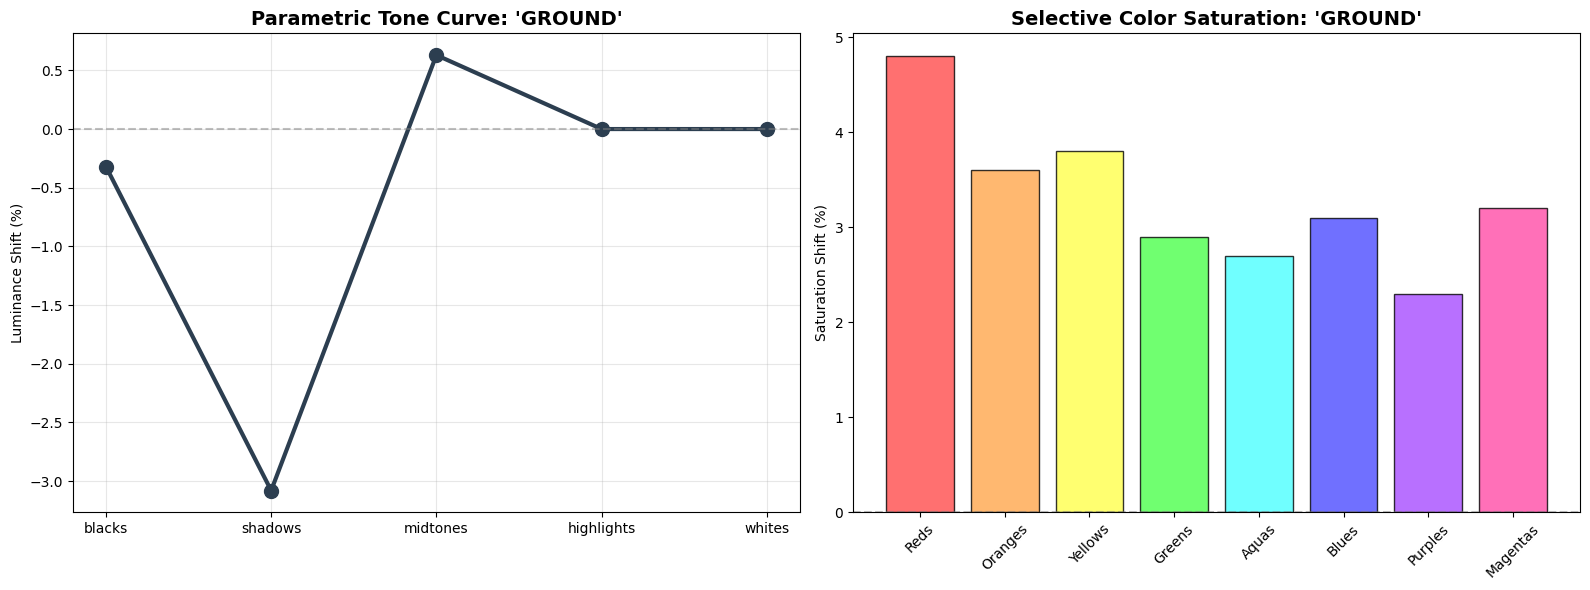

In [11]:
# --- Pipeline 03: Full Extraction & Validation Engine ---
import os
import cv2
import numpy as np
import torch
import kornia
from PIL import Image
import json
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from collections import defaultdict
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# --- 1. The Bulletproof Color Extractor ---
class AdvancedColorExtractor:
    def __init__(self, device, min_pixels=1000):
        self.device = device
        self.min_pixels = min_pixels
        self.hue_bins = {
            'reds':     ((345, 360), (0, 15)),
            'oranges':  ((15, 45),),
            'yellows':  ((45, 75),),
            'greens':   ((75, 135),),
            'aquas':    ((135, 195),),
            'blues':    ((195, 255),),
            'purples':  ((255, 315),),
            'magentas': ((315, 345),)
        }

    def _get_luminance(self, tensor: torch.Tensor) -> torch.Tensor:
        """Calculates Rec. 601 Luma from an RGB tensor [3, H, W]"""
        return 0.299 * tensor[0] + 0.587 * tensor[1] + 0.114 * tensor[2]

    def extract_tone_curve(self, raw_lum: torch.Tensor, edt_lum: torch.Tensor) -> dict:
        curve = {}
        ranges = {
            'blacks': (0.0, 0.1), 'shadows': (0.1, 0.35), 'midtones': (0.35, 0.65),
            'highlights': (0.65, 0.9), 'whites': (0.9, 1.0)
        }
        for name, (low, high) in ranges.items():
            mask = (raw_lum >= low) & (raw_lum < high)
            if mask.sum() > 50:
                shift = torch.median(edt_lum[mask]) - torch.median(raw_lum[mask])
                curve[name] = round(shift.item() * 100, 2)
            else:
                curve[name] = 0.0
        return curve

    def extract_hsl_mixer(self, raw_hsv: torch.Tensor, edt_hsv: torch.Tensor) -> dict:
        mixer = {}
        raw_hue_deg = raw_hsv[:, 0] * 360.0
        for color, conditions in self.hue_bins.items():
            mask = torch.zeros_like(raw_hue_deg, dtype=torch.bool)
            for (low, high) in conditions:
                mask |= (raw_hue_deg >= low) & (raw_hue_deg < high)

            if mask.sum() > 50:
                # Handles circular hue wrap-around (e.g. Red shifting backward)
                h_diff = edt_hsv[mask, 0] - raw_hsv[mask, 0]
                h_diff = (h_diff + 0.5) % 1.0 - 0.5
                h_shift = torch.median(h_diff) * 360.0
                s_shift = torch.median(edt_hsv[mask, 1] - raw_hsv[mask, 1]) * 100.0
                l_shift = torch.median(edt_hsv[mask, 2] - raw_hsv[mask, 2]) * 100.0
                mixer[color] = {
                    'h': round(h_shift.item(), 1), 's': round(s_shift.item(), 1), 'l': round(l_shift.item(), 1)
                }
        return mixer

    @torch.no_grad()
    def process_pair(self, raw_np: np.ndarray, edt_np: np.ndarray, regions: dict) -> dict:
        raw_t = kornia.image_to_tensor(raw_np, keepdim=False).to(self.device).float() / 255.0
        edt_t = kornia.image_to_tensor(edt_np, keepdim=False).to(self.device).float() / 255.0

        raw_hsv = kornia.color.rgb_to_hsv(raw_t).squeeze(0).permute(1, 2, 0)
        edt_hsv = kornia.color.rgb_to_hsv(edt_t).squeeze(0).permute(1, 2, 0)

        raw_lum = self._get_luminance(raw_t.squeeze(0))
        edt_lum = self._get_luminance(edt_t.squeeze(0))

        profiles = {}
        for label, mask_np in regions.items():
            mask_t = torch.from_numpy(mask_np).to(self.device).bool()
            if mask_t.sum() < self.min_pixels: continue
            profiles[label] = {
                'tone_curve': self.extract_tone_curve(raw_lum[mask_t], edt_lum[mask_t]),
                'color_mixer': self.extract_hsl_mixer(raw_hsv[mask_t], edt_hsv[mask_t])
            }
        return profiles

# --- 2. File Alignment & Heuristics ---
def get_number(filename):
    name = filename.replace('.jpg', '')
    for prefix in ['raw_', 'edited_', 'raw', 'edited']: name = name.replace(prefix, '')
    return int(name)

raw_map = {get_number(f): f for f in os.listdir(RAW_DIR) if f.lower().endswith('.jpg')}
edt_map = {get_number(f): f for f in os.listdir(EDITED_DIR) if f.lower().endswith('.jpg')}
common_nums = sorted(set(raw_map.keys()) & set(edt_map.keys()))
paired_files = [(raw_map[n], edt_map[n]) for n in common_nums]

def get_mask_properties(mask, image_np):
    h, w = mask.shape
    ys, xs = np.where(mask)
    if len(ys) == 0: return None
    return {
        'area_ratio': mask.sum() / (h * w), 'center_y': ys.mean() / h, 'center_x': xs.mean() / w,
        'mean_rgb': image_np[mask].mean(axis=0), 'mean_brightness': image_np[mask].mean(axis=0).mean() / 255.0,
        'top_half_ratio': (ys < h / 2).sum() / len(ys)
    }

def classify_mask_heuristic(props):
    if props is None: return 'unknown', 0.0
    r, g, b = props['mean_rgb']
    if props['top_half_ratio'] > 0.8 and props['area_ratio'] > 0.05 and props['mean_brightness'] > 0.4 and b > r * 0.8: return 'sky', 0.8
    elif props['center_y'] > 0.6 and props['area_ratio'] > 0.1 and props['top_half_ratio'] < 0.3: return 'ground', 0.6
    elif props['area_ratio'] > 0.5: return 'background', 0.5
    return 'unknown', 0.0

# --- 3. SAM Setup (The Bug Fix is Here) ---
print("Loading SAM Model to GPU...")
SAM_CHECKPOINT = f'{PROJECT}/checkpoints/sam_vit_h_4b8939.pth'
sam = sam_model_registry['vit_h'](checkpoint=SAM_CHECKPOINT).to(device)

# BUG FIX: min_mask_region_area=0 bypasses the broken OpenCV bridging in SAM.
auto_generator = SamAutomaticMaskGenerator(sam, points_per_side=32, pred_iou_thresh=0.86, stability_score_thresh=0.92, min_mask_region_area=0)
extractor = AdvancedColorExtractor(device=device, min_pixels=1000)
master_stats = defaultdict(lambda: {'tone_curve': defaultdict(list), 'color_mixer': defaultdict(lambda: defaultdict(list))})

# --- 4. The Extraction Loop ---
print(f"Extracting Non-Linear Color Science from {len(paired_files)} pairs...")
for raw_f, edt_f in tqdm(paired_files, desc="Tensor Extraction"):
    try:
        raw_img = np.array(Image.open(os.path.join(RAW_DIR, raw_f)).convert("RGB"))
        edt_img = np.array(Image.open(os.path.join(EDITED_DIR, edt_f)).convert("RGB"))

        scale = 1024 / max(raw_img.shape[0], raw_img.shape[1])
        new_size = (int(raw_img.shape[1] * scale), int(raw_img.shape[0] * scale))
        raw_eval = cv2.resize(raw_img, new_size)
        edt_eval = cv2.resize(edt_img, new_size)

        raw_masks = auto_generator.generate(raw_eval)
        raw_masks = sorted(raw_masks, key=lambda x: x['area'], reverse=True)[:8]

        labeled_regions = {}
        for idx, mask_data in enumerate(raw_masks):
            mask = mask_data['segmentation']
            props = get_mask_properties(mask, raw_eval)
            h_label, h_conf = classify_mask_heuristic(props)
            label = h_label if h_conf >= 0.6 else mask_label_cache.get(raw_f, {}).get(str(idx), 'unknown')
            if label != 'unknown': labeled_regions[label] = mask

        pair_profiles = extractor.process_pair(raw_eval, edt_eval, labeled_regions)
        for label, data in pair_profiles.items():
            for k, v in data['tone_curve'].items(): master_stats[label]['tone_curve'][k].append(v)
            for color, shifts in data['color_mixer'].items():
                for k, v in shifts.items(): master_stats[label]['color_mixer'][color][k].append(v)

    except Exception as e: print(f"Error processing {raw_f}: {e}")

# --- 5. Aggregation & Export ---
final_color_profile = {}
for label, data in master_stats.items():
    sample_size = len(list(data['tone_curve'].values())[0]) if data['tone_curve'] else 0
    if sample_size < (len(paired_files) * 0.05): continue

    final_color_profile[label] = {'tone_curve': {}, 'color_mixer': {}}
    for band, values in data['tone_curve'].items():
        if values: final_color_profile[label]['tone_curve'][band] = round(float(np.median(values)), 2)

    for color, shifts in data['color_mixer'].items():
        final_color_profile[label]['color_mixer'][color] = {
            'h': round(float(np.median(shifts['h'])), 1) if shifts['h'] else 0.0,
            's': round(float(np.median(shifts['s'])), 1) if shifts['s'] else 0.0,
            'l': round(float(np.median(shifts['l'])), 1) if shifts['l'] else 0.0
        }

output_path = f'{PROJECT}/checkpoints/simon_advanced_color_profile.json'
with open(output_path, 'w') as f: json.dump(final_color_profile, f, indent=4)
print(f"✅ S-Curve and HSL Data successfully saved to {output_path}")

# --- 6. Validation Visualization ---
if len(final_color_profile) > 0:
    test_region = list(final_color_profile.keys())[0]
    region_data = final_color_profile[test_region]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    bands = ['blacks', 'shadows', 'midtones', 'highlights', 'whites']
    shifts = [region_data['tone_curve'].get(b, 0) for b in bands]
    ax1.plot(bands, shifts, marker='o', color='#2c3e50', linewidth=3, markersize=10)
    ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax1.set_title(f"Parametric Tone Curve: '{test_region.upper()}'", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Luminance Shift (%)")
    ax1.grid(True, alpha=0.3)

    colors = ['reds', 'oranges', 'yellows', 'greens', 'aquas', 'blues', 'purples', 'magentas']
    color_hex = ['#ff4c4c', '#ffa64c', '#ffff4c', '#4cff4c', '#4cffff', '#4c4cff', '#a64cff', '#ff4ca6']
    sat_shifts = [region_data['color_mixer'].get(c, {}).get('s', 0) for c in colors]

    x = np.arange(len(colors))
    ax2.bar(x, sat_shifts, color=color_hex, alpha=0.8, edgecolor='black')
    ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax2.set_xticks(x)
    ax2.set_xticklabels([c.capitalize() for c in colors], rotation=45)
    ax2.set_title(f"Selective Color Saturation: '{test_region.upper()}'", fontsize=14, fontweight='bold')
    ax2.set_ylabel("Saturation Shift (%)")

    plt.tight_layout()
    plt.show()